# DBSCAN Clustering from Scratch

The aim of this notebook is to implement **DBSCAN** clustering algorithm from scratch using only NumPy.

In [20]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

In [2]:
# Load synthetic dataset
X, y = make_moons(n_samples=300, noise=0.1, random_state=42)

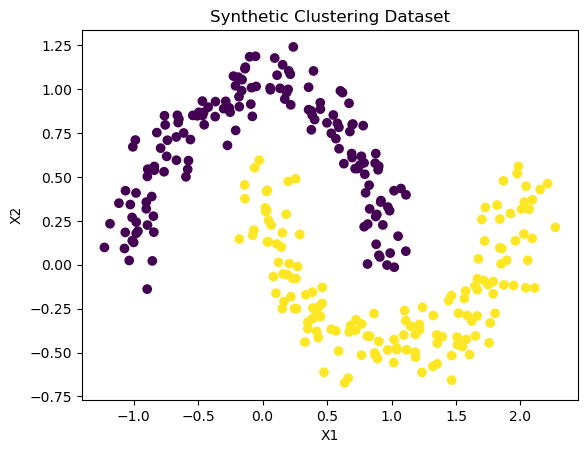

In [3]:
# Visualization
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Synthetic Clustering Dataset")
plt.show()

### Reasoning

What DBSCAN does, step by step:

We have 300 points. Initially, all are labeled -1 (noise).

**label_points** iterates through each point one by one:

- For point 0: how many neighbors are there within radius epsilon?
  - Fewer than min_samples → it remains noise, so we move on to the next one
  - At least min_samples → it’s a core point, we create cluster 0, and we expand this cluster

“Expanding” the cluster is the job of **expand_cluster**:

- We have a list of neighbors to process (the queue).
- We take the first neighbor from the queue.
  - If it’s already in a cluster → we skip
  - If it is noise (-1) → assign it to the current cluster
  - Calculate its own neighbors
    - If it is a core point → add its neighbors to the queue (the cluster continues to grow)
    - Otherwise → it is a border point, stop there for it
- Move on to the next neighbor in the queue
- When the queue is empty → the cluster is complete

In [15]:
# Get neighbors of point of index point_idx within eps distance
def get_neighbors(X, point_idx, eps):
    distances = np.linalg.norm(X - X[point_idx], axis=1)
    return list(np.where(distances <= eps)[0])

In [16]:
# Expand cluster from point_idx
def expand_cluster(X, labels, neighbors, cluster_id, eps, min_samples):
    queue = list(neighbors)
    while queue:
        neighbor_idx = queue.pop(0)
        if labels[neighbor_idx] != -1:  # Already classified as noise or part of another cluster
            continue
        else: # Unvisited
            labels[neighbor_idx] = cluster_id
            new_neighbors = get_neighbors(X, neighbor_idx, eps)
            if len(new_neighbors) >= min_samples:
                queue.extend(new_neighbors)

In [17]:
# Label points based on DBSCAN criteria
def label_points(X, eps, min_samples):
    # Initialize all points as noise (label -1)
    labels = np.full(X.shape[0], -1)  
    cluster_id = 0

    # Iterate through each point in the dataset
    for point_idx in range(X.shape[0]):
        if labels[point_idx] != -1:
            continue  # Skip already labeled points

        neighbors = get_neighbors(X, point_idx, eps)

        # If number of neighbors is less than min_samples, mark as noise
        if len(neighbors) >= min_samples:
            labels[point_idx] = cluster_id  # Assign cluster ID
            expand_cluster(X, labels, neighbors, cluster_id, eps, min_samples)
            cluster_id += 1

    return labels

In [18]:
# Test with the dataset
labels = label_points(X, eps=0.2, min_samples=5)
print(np.unique(labels))

[0 1]


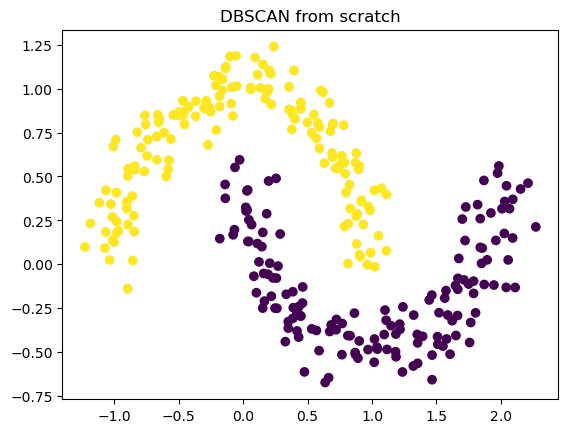

In [19]:
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title("DBSCAN from scratch")
plt.show()

In [21]:
# Scikit-Learn comparison
sk_model = DBSCAN(eps=0.2, min_samples=5)
sk_labels = sk_model.fit_predict(X)

print("Scratch clusters:", np.unique(labels))
print("Sklearn clusters:", np.unique(sk_labels))

Scratch clusters: [0 1]
Sklearn clusters: [0 1]
